### Load company stock close price data

In [1]:
import yfinance as yf

tickers_ev = ["TSLA", "NIO", "BYDDF", "TM"]
data = yf.download(tickers_ev, start="2010-01-01")['Close']

data = data.reset_index()
data = data.sort_values(by="Date")
data = data.dropna()

data.columns = ['Date'] + [f"{ticker}_close" for ticker in data.columns[1:]]
data = data.set_index('Date')
data.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  4 of 4 completed


,BYDDF_close,NIO_close,TM_close,TSLA_close
Date,,,,
2018-09-12,5.542323,6.60,101.459381,19.369333
2018-09-13,5.707911,11.60,103.193932,19.297333
2018-09-14,6.107269,9.90,103.464684,19.680000
2018-09-17,6.000124,8.50,103.633934,19.656000
2018-09-18,6.039086,7.68,105.791557,18.997334


### Load ETF Commodity Data

In [2]:
# ETF symbols related to EV production metals
etf_symbols = ['LIT', 'COPX', 'DBB', 'PICK', 'REMX', 'URA', 'BATT']
etf_data = yf.download(etf_symbols, start="2010-01-01")['Close']
etf_data = etf_data.reset_index()
etf_data.columns = ['date'] + [f"{symbol}_close" for symbol in etf_data.columns[1:]]
etf_data = etf_data.sort_values(by="date")
etf_data = etf_data.dropna().set_index('date')
etf_data

[*********************100%***********************]  7 of 7 completed


,BATT_close,COPX_close,DBB_close,LIT_close,PICK_close,REMX_close,URA_close
date,,,,,,,
2018-06-06,17.174940,23.846457,16.505632,31.735638,26.522394,61.331043,12.131795
2018-06-07,16.698212,23.733767,16.301439,31.542244,26.268480,60.496437,11.752419
2018-06-08,16.629021,23.551735,16.548174,31.542244,26.116140,60.257977,11.768914
2018-06-11,16.537893,23.595076,16.480112,31.652756,26.174171,60.329521,11.818398
2018-06-12,16.251013,23.447712,16.437567,31.671179,25.833214,59.351845,11.727676
...,...,...,...,...,...,...,...
2025-05-20,8.730000,39.959999,18.709999,38.230000,36.860001,38.110001,28.010000
2025-05-21,8.770000,40.180000,18.540001,37.869999,36.580002,36.919998,28.230000
2025-05-22,8.680000,40.209999,18.520000,37.610001,36.509998,37.270000,28.520000


In [3]:
import numpy as np
import pandas as pd

# Filter out any zero or negative values BEFORE log return calculation
ev_stocks = data.replace(0, np.nan)
ev_stocks[ev_stocks < 0] = np.nan

metal_etfs = etf_data.replace(0, np.nan)
metal_etfs[metal_etfs < 0] = np.nan

ev_stocks.head()

,BYDDF_close,NIO_close,TM_close,TSLA_close
Date,,,,
2018-09-12,5.542323,6.60,101.459381,19.369333
2018-09-13,5.707911,11.60,103.193932,19.297333
2018-09-14,6.107269,9.90,103.464684,19.680000
2018-09-17,6.000124,8.50,103.633934,19.656000
2018-09-18,6.039086,7.68,105.791557,18.997334


## EDA

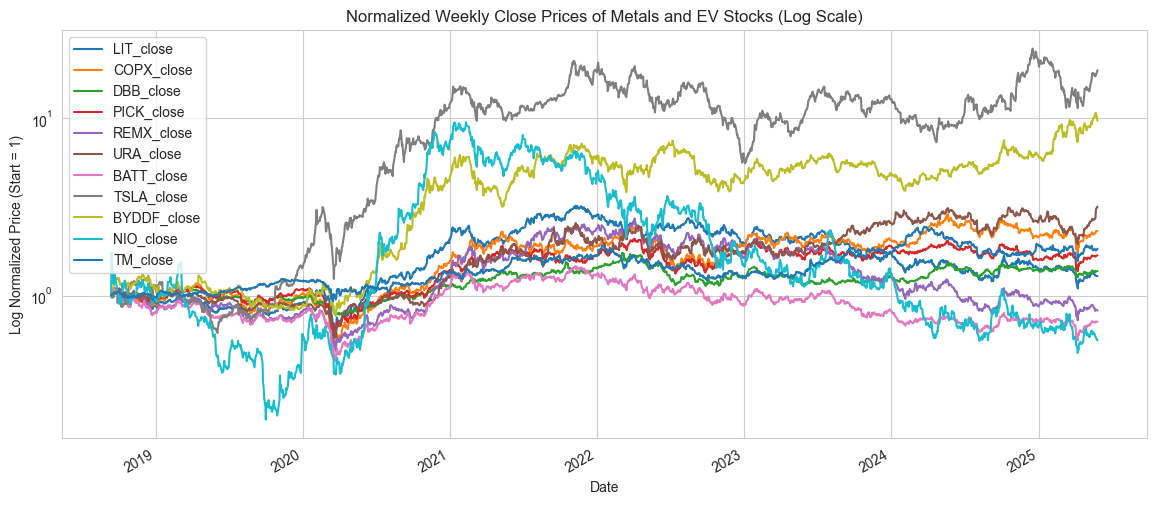

In [4]:
import matplotlib.pyplot as plt

# Combine relevant columns from both dataframes by aligning on date index
full_df = pd.concat([
    metal_etfs[['LIT_close', 'COPX_close', 'DBB_close', 'PICK_close', 'REMX_close', 'URA_close', 'BATT_close']],
    ev_stocks[['TSLA_close', 'BYDDF_close', 'NIO_close', 'TM_close']]
], axis=1)

# Drop rows with any missing data to get the inner join effect
full_df = full_df.dropna()

# Normalize all columns to start at 1
normalized_df = full_df / full_df.iloc[0]

# Plot
normalized_df.plot(figsize=(14,6), title='Normalized Weekly Close Prices of Metals and EV Stocks (Log Scale)')
plt.xlabel('Date')
plt.ylabel('Log Normalized Price (Start = 1)')
plt.yscale('log')
plt.grid(True)
plt.show()

### Feature Engineering - Log Returns

,LIT_log_ret,COPX_log_ret,DBB_log_ret,PICK_log_ret,REMX_log_ret,URA_log_ret,BATT_log_ret,TSLA_log_ret,BYDDF_log_ret,NIO_log_ret,TM_log_ret
2018-09-13,0.007918,0.011566,-0.009437,0.008000,0.001591,0.003973,0.014966,-0.003724,0.029439,0.563935,0.016952
2018-09-14,0.009419,-0.001919,-0.016571,0.008595,0.006866,-0.002382,-0.004738,0.019636,0.067627,-0.158470,0.002620
2018-09-17,0.004054,0.000480,0.008957,0.000000,-0.011114,0.000795,-0.002717,-0.001220,-0.017700,-0.152469,0.001634
2018-09-18,0.008677,0.020424,0.016425,0.021814,0.018978,0.013413,0.013447,-0.034084,0.006473,-0.101447,0.020606
2018-09-19,0.016221,0.027818,0.003128,0.024811,0.014516,-0.002354,0.015386,0.048162,0.071570,0.101447,0.002317


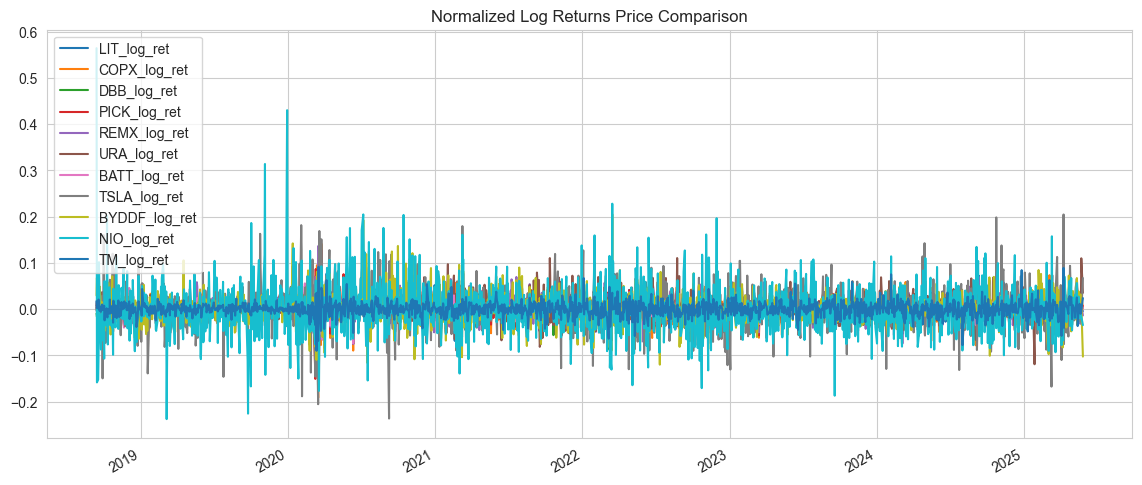

In [5]:
close_cols = [col for col in full_df.columns if "close" in col.lower()]

# log returns
for close in close_cols:
    name = close.split("_")[0]
    log_ret_col = f"{name}_log_ret"
    full_df[log_ret_col] = np.log(full_df[close] / full_df[close].shift(1))
    
raw_patterns = ('close', 'open', 'high', 'low', 'volume')
raw_cols = [c for c in full_df.columns if c.endswith(raw_patterns)]
full_df = full_df.drop(columns=raw_cols)

# Subset log returns for plotting
log_ret_cols = [col for col in full_df.columns if col.endswith("_log_ret")]
full_df[log_ret_cols].plot(figsize=(14, 6), title='Normalized Log Returns Price Comparison')
full_df.dropna().head()

### Granger Causality

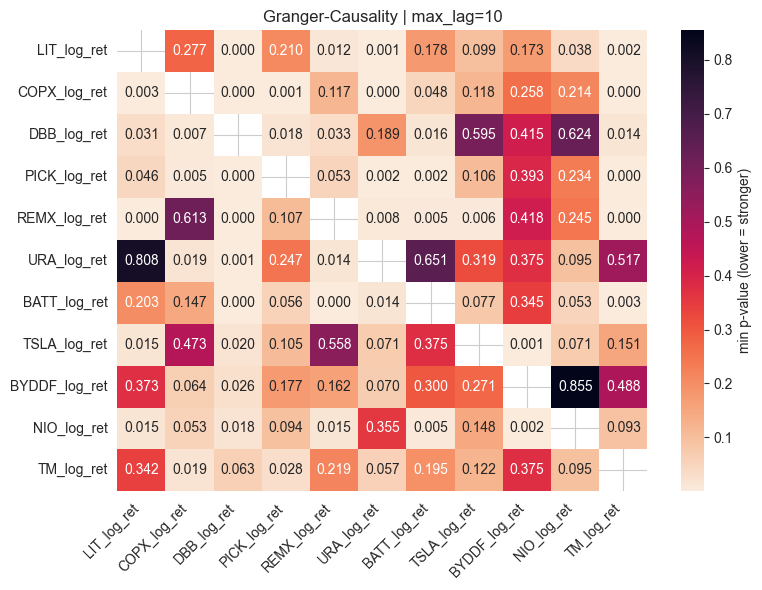

,LIT_log_ret,COPX_log_ret,DBB_log_ret,PICK_log_ret,REMX_log_ret,URA_log_ret,BATT_log_ret,TSLA_log_ret,BYDDF_log_ret,NIO_log_ret,TM_log_ret
LIT_log_ret,False,False,True,False,True,True,False,False,False,True,True
COPX_log_ret,True,False,True,True,False,True,True,False,False,False,True
DBB_log_ret,True,True,False,True,True,False,True,False,False,False,True
PICK_log_ret,True,True,True,False,False,True,True,False,False,False,True
REMX_log_ret,True,False,True,False,False,True,True,True,False,False,True
URA_log_ret,False,True,True,False,True,False,False,False,False,False,False
BATT_log_ret,False,False,True,False,True,True,False,False,False,False,True
TSLA_log_ret,True,False,True,False,False,False,False,False,True,False,False
BYDDF_log_ret,False,False,True,False,False,False,False,False,False,False,False
NIO_log_ret,True,False,True,False,True,False,True,False,True,False,False


p_value
COPX_log_ret DBB_log_ret   7.656527e-09
PICK_log_ret DBB_log_ret   1.600365e-07
             TM_log_ret    2.824727e-06
REMX_log_ret DBB_log_ret   3.253631e-06
COPX_log_ret URA_log_ret   1.659161e-05
             TM_log_ret    1.904029e-05
BATT_log_ret DBB_log_ret   4.288617e-05
LIT_log_ret  DBB_log_ret   1.573348e-04
BATT_log_ret REMX_log_ret  1.627128e-04
REMX_log_ret TM_log_ret    2.931415e-04

In [6]:
import pandas as pd
import numpy as np
import itertools
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="statsmodels")

max_lag   = 10
alpha     = 0.05 # significance threshold
plot_heat = True

log_returns = full_df[log_ret_cols].dropna()

min_rows_needed = (max_lag + 2) * 2 # rule-of-thumb
if len(log_returns) < min_rows_needed:
    raise ValueError(
        f"Only {len(log_returns)} rows—reduce max_lag below "
        f"{(len(log_returns)//2)-2} or fetch more history."
    )

# pairwise Granger
pv_matrix = pd.DataFrame(
    np.nan, index=log_ret_cols, columns=log_ret_cols, dtype=float
)
best_lags = {}

for x, y in itertools.permutations(log_ret_cols, 2):
    pvals = []
    for lag in range(1, max_lag + 1):
        try:
            test = sm.tsa.stattools.grangercausalitytests(
                log_returns[[x, y]], maxlag=lag, verbose=False
            )
            # F-test p-value for this lag
            p = test[lag][0]["ssr_ftest"][1]
            pvals.append((lag, p))
        except Exception:
            # happens if lag > samples/2 or series is collinear
            continue
    if pvals:
        # pick the lag with the *lowest* p-value
        best_lag, best_p = min(pvals, key=lambda tup: tup[1])
        pv_matrix.loc[y, x] = best_p      # y → x
        best_lags[(y, x)] = best_lag

# causal flags + viz
causal_flags = pv_matrix < alpha

if plot_heat:
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        pv_matrix, annot=True, cmap="rocket_r", fmt=".3f",
        cbar_kws={'label': 'min p-value (lower = stronger)'}
    )
    plt.title(f"Granger-Causality | max_lag={max_lag}")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

display(causal_flags)   # Boolean matrix: True = “Y Granger-causes X”

# optional: inspect strongest links
(
    pv_matrix.stack()
    .sort_values()
    .to_frame("p_value")
    .loc[lambda df: df["p_value"] < alpha]
    .head(10)
)

## Ridge Regression with Lags

In [15]:
best_lags

{('COPX_log_ret', 'LIT_log_ret'): 1,
 ('DBB_log_ret', 'LIT_log_ret'): 6,
 ('PICK_log_ret', 'LIT_log_ret'): 6,
 ('REMX_log_ret', 'LIT_log_ret'): 1,
 ('URA_log_ret', 'LIT_log_ret'): 4,
 ('BATT_log_ret', 'LIT_log_ret'): 2,
 ('TSLA_log_ret', 'LIT_log_ret'): 3,
 ('BYDDF_log_ret', 'LIT_log_ret'): 7,
 ('NIO_log_ret', 'LIT_log_ret'): 1,
 ('TM_log_ret', 'LIT_log_ret'): 1,
 ('LIT_log_ret', 'COPX_log_ret'): 4,
 ('DBB_log_ret', 'COPX_log_ret'): 5,
 ('PICK_log_ret', 'COPX_log_ret'): 4,
 ('REMX_log_ret', 'COPX_log_ret'): 3,
 ('URA_log_ret', 'COPX_log_ret'): 5,
 ('BATT_log_ret', 'COPX_log_ret'): 7,
 ('TSLA_log_ret', 'COPX_log_ret'): 1,
 ('BYDDF_log_ret', 'COPX_log_ret'): 7,
 ('NIO_log_ret', 'COPX_log_ret'): 1,
 ('TM_log_ret', 'COPX_log_ret'): 1,
 ('LIT_log_ret', 'DBB_log_ret'): 2,
 ('COPX_log_ret', 'DBB_log_ret'): 2,
 ('PICK_log_ret', 'DBB_log_ret'): 2,
 ('REMX_log_ret', 'DBB_log_ret'): 2,
 ('URA_log_ret', 'DBB_log_ret'): 1,
 ('BATT_log_ret', 'DBB_log_ret'): 2,
 ('TSLA_log_ret', 'DBB_log_ret'): 3,
 (

In [7]:
# Use log_returns from earlier
targets = ['TSLA_log_ret', 'NIO_log_ret', 'BYDDF_log_ret', 'TM_log_ret']
predictors = [c for c in log_returns.columns if c not in targets]

lagged_df = log_returns.copy()
lagged_features = []

for lag in range(1, 10):
    lagged = log_returns[predictors].shift(lag)
    lagged.columns = [f"{col}_lag{lag}" for col in lagged.columns]
    lagged_features.append(lagged)

lagged_feature_df = pd.concat(lagged_features, axis=1)

# combine with targets
lagged_df = pd.concat([lagged_feature_df, log_returns[targets]], axis=1).dropna()

feature_cols = [col for col in lagged_df.columns if 'lag' in col]

split_idx = int(len(lagged_df) * 0.7)
X = lagged_df[feature_cols]
Y = lagged_df[targets]
X.head()

,LIT_log_ret_lag1,COPX_log_ret_lag1,DBB_log_ret_lag1,PICK_log_ret_lag1,REMX_log_ret_lag1,URA_log_ret_lag1,BATT_log_ret_lag1,LIT_log_ret_lag2,COPX_log_ret_lag2,DBB_log_ret_lag2,...,REMX_log_ret_lag8,URA_log_ret_lag8,BATT_log_ret_lag8,LIT_log_ret_lag9,COPX_log_ret_lag9,DBB_log_ret_lag9,PICK_log_ret_lag9,REMX_log_ret_lag9,URA_log_ret_lag9,BATT_log_ret_lag9
2018-09-26,-0.006253,-0.000447,0.005456,0.014661,0.001965,0.008511,-0.001276,0.000297,-0.014631,-0.006061,...,0.006866,-0.002382,-0.004738,0.007918,0.011566,-0.009437,0.008000,0.001591,0.003973,0.014966
2018-09-27,-0.004790,-0.007625,-0.001815,-0.009138,-0.008377,-0.011624,-0.003198,-0.006253,-0.000447,0.005456,...,-0.011114,0.000795,-0.002717,0.009419,-0.001919,-0.016571,0.008595,0.006866,-0.002382,-0.004738
2018-09-28,0.001200,-0.008591,-0.010350,-0.001225,-0.005458,0.036729,-0.012700,-0.004790,-0.007625,-0.001815,...,0.018978,0.013413,0.013447,0.004054,0.000480,0.008957,0.000000,-0.011114,0.000795,-0.002717
2018-10-01,-0.012366,0.003174,0.016991,-0.001533,0.003477,0.000000,0.001750,0.001200,-0.008591,-0.010350,...,0.014516,-0.002354,0.015386,0.008677,0.020424,0.016425,0.021814,0.018978,0.013413,0.013447
2018-10-02,0.007558,0.006768,0.009581,0.003981,0.001981,0.006739,0.010309,-0.012366,0.003174,0.016991,...,0.031411,0.014041,0.027381,0.016221,0.027818,0.003128,0.024811,0.014516,-0.002354,0.015386


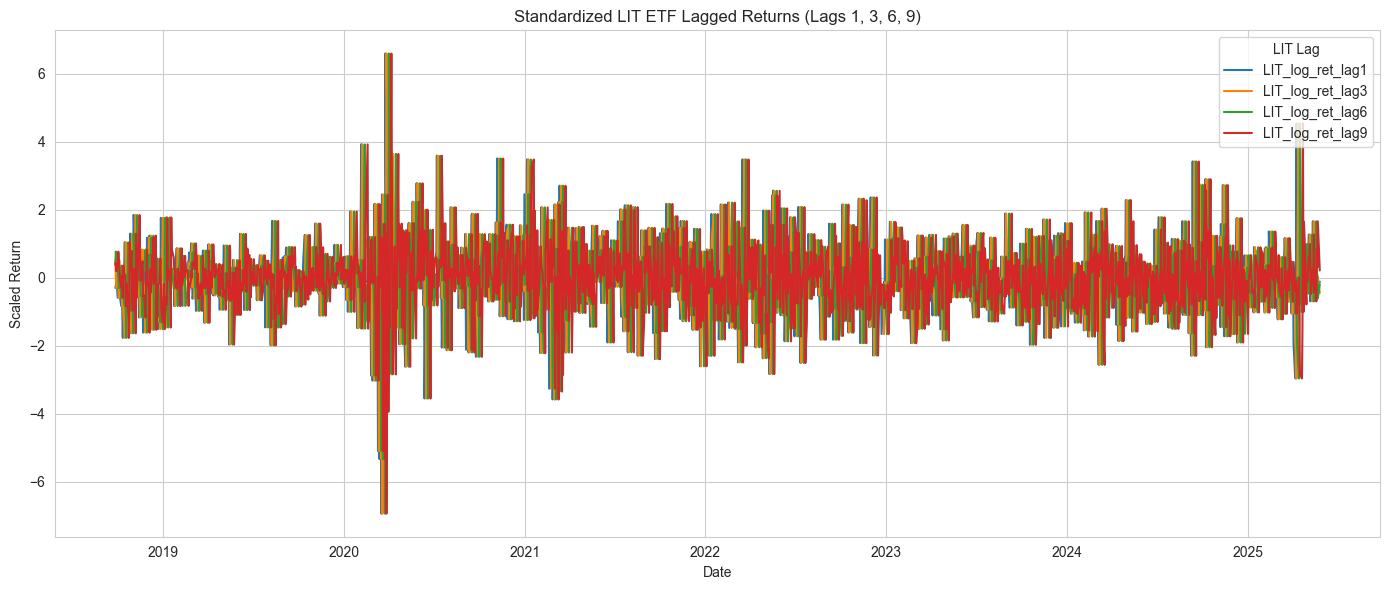

In [18]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Select specific LIT lag features
lit_lags = ['LIT_log_ret_lag1', 'LIT_log_ret_lag3', 'LIT_log_ret_lag6', 'LIT_log_ret_lag9']
lit_df = X[lit_lags].copy()

# Scale them for visualization
scaled_lit = pd.DataFrame(
    StandardScaler().fit_transform(lit_df),
    index=lit_df.index,
    columns=lit_df.columns
)

# Plot
plt.figure(figsize=(14, 6))
for col in scaled_lit.columns:
    plt.plot(scaled_lit.index, scaled_lit[col], label=col)

plt.title("Standardized LIT ETF Lagged Returns (Lags 1, 3, 6, 9)")
plt.xlabel("Date")
plt.ylabel("Scaled Return")
plt.legend(title="LIT Lag", loc="upper right")
plt.tight_layout()
plt.show()

In [8]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# split the lagged-feature dataset (already built above)
split_idx  = int(len(X) * 0.7)      # 70 % chronological split
X_train, X_test = X.iloc[:split_idx],  X.iloc[split_idx:]
Y_train, Y_test = Y.iloc[:split_idx], Y.iloc[split_idx:]

# train a single multi-output RidgeCV model
#    (RidgeCV natively handles DataFrame targets)
ridge_pipe = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=[0.1, 1, 10, 100], cv=5)
)

ridge_pipe.fit(X_train, Y_train)
Y_pred = pd.DataFrame(ridge_pipe.predict(X_test),
                      index=Y_test.index,
                      columns=Y_test.columns)

# evaluate per-target MSE
mse_scores = {
    tgt: mean_squared_error(Y_test[tgt], Y_pred[tgt])
    for tgt in Y_test.columns
}

rmse_scores = {
    tgt: np.sqrt(mse)
    for tgt, mse in mse_scores.items()
}

usd_per_unit_error = 0.50  # <-- adjust this as needed!

usd_loss_scores = {
    tgt: rmse * usd_per_unit_error
    for tgt, rmse in rmse_scores.items()
}

results_df = (
    pd.DataFrame({
        "MSE": mse_scores,
        "RMSE": rmse_scores,
        "USD_Loss": usd_loss_scores
    })
    .assign(
        best_alpha=ridge_pipe.named_steps["ridgecv"].alpha_,
        n_feats=X_train.shape[1]
    )
)

print("=== Ridge baseline: MSE, RMSE, and USD Loss ===")
print(results_df)
ridge_model = ridge_pipe

=== Ridge baseline: MSE, RMSE, and USD Loss ===
                    MSE      RMSE  USD_Loss  best_alpha  n_feats
TSLA_log_ret   0.001590  0.039874  0.019937       100.0       63
NIO_log_ret    0.001954  0.044204  0.022102       100.0       63
BYDDF_log_ret  0.000726  0.026940  0.013470       100.0       63
TM_log_ret     0.000326  0.018043  0.009021       100.0       63


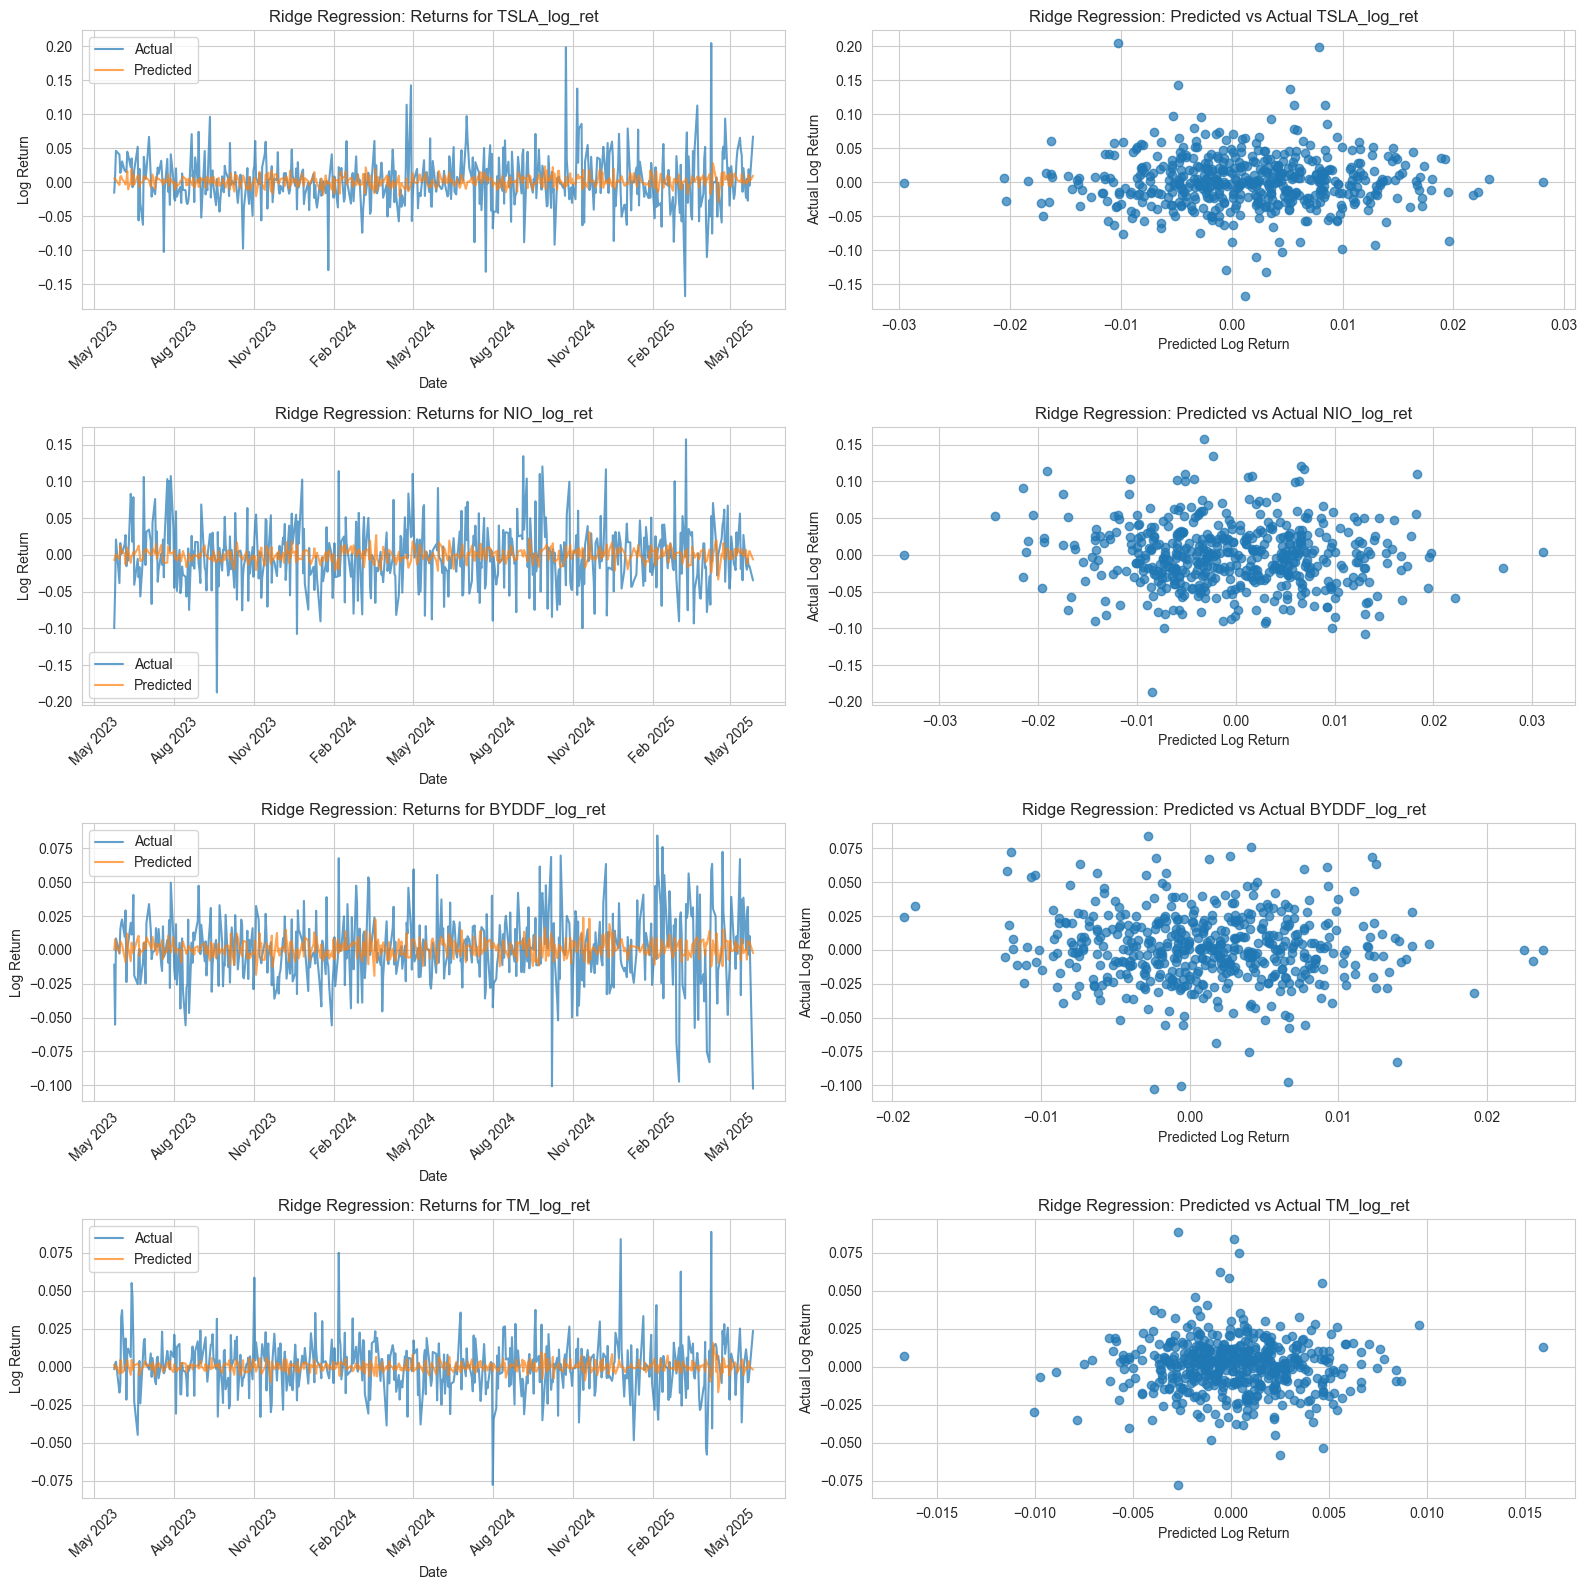

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# Use same split
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
Y_train, Y_test = Y.iloc[:split_idx], Y.iloc[split_idx:]

# Predict all at once using fitted multi-output Ridge
Y_pred_all = pd.DataFrame(
    ridge_model.predict(X_test),
    index=Y_test.index,
    columns=Y_test.columns
)

# --- Plot ---
plt.figure(figsize=(16, 4 * len(targets)))

for i, tgt in enumerate(targets, 1):
    y_test = Y_test[tgt]
    y_pred = Y_pred_all[tgt]

    # Left: Time-series line plot
    plt.subplot(len(targets), 2, 2*i - 1)
    plt.plot(y_test.index, y_test, label='Actual', alpha=0.7)
    plt.plot(y_pred.index, y_pred, label='Predicted', alpha=0.7)
    plt.title(f'Ridge Regression: Returns for {tgt}')
    plt.xlabel('Date')
    plt.ylabel('Log Return')
    plt.legend()
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)

    # Right: Scatter plot predicted vs actual
    plt.subplot(len(targets), 2, 2*i)
    plt.scatter(y_pred, y_test, alpha=0.7)
    plt.title(f'Ridge Regression: Predicted vs Actual {tgt}')
    plt.xlabel('Predicted Log Return')
    plt.ylabel('Actual Log Return')
    plt.grid(True)

plt.tight_layout()
plt.show()

## MultiOutput XGBoost

In [10]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

# Data split (same X, Y as Ridge)
split_idx = int(len(X) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
Y_train, Y_test = Y.iloc[:split_idx], Y.iloc[split_idx:]

# XGBoost multi-output model
xgb_base = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42
)
xgb_model = MultiOutputRegressor(xgb_base)
xgb_model.fit(X_train, Y_train)

Y_pred_xgb = pd.DataFrame(
    xgb_model.predict(X_test),
    index=Y_test.index,
    columns=Y_test.columns
)

# MSE ➜ RMSE ➜ USD-loss
mse_xgb = {
    tgt: mean_squared_error(Y_test[tgt], Y_pred_xgb[tgt])
    for tgt in Y_test.columns
}
rmse_xgb = {tgt: np.sqrt(mse) for tgt, mse in mse_xgb.items()}

usd_per_unit_error = 0.50
usd_loss_xgb = {tgt: rmse * usd_per_unit_error for tgt, rmse in rmse_xgb.items()}

xgb_results = (pd.DataFrame({
                    "MSE": mse_xgb,
                    "RMSE": rmse_xgb,
                    "USD_Loss": usd_loss_xgb
               })
               .sort_index())

print("=== XGB – MSE, RMSE, USD Loss ===")
print(xgb_results.round(6))

=== XGB – MSE, RMSE, USD Loss ===
                    MSE      RMSE  USD_Loss
BYDDF_log_ret  0.000754  0.027465  0.013733
NIO_log_ret    0.002073  0.045535  0.022768
TM_log_ret     0.000325  0.018041  0.009020
TSLA_log_ret   0.001601  0.040016  0.020008


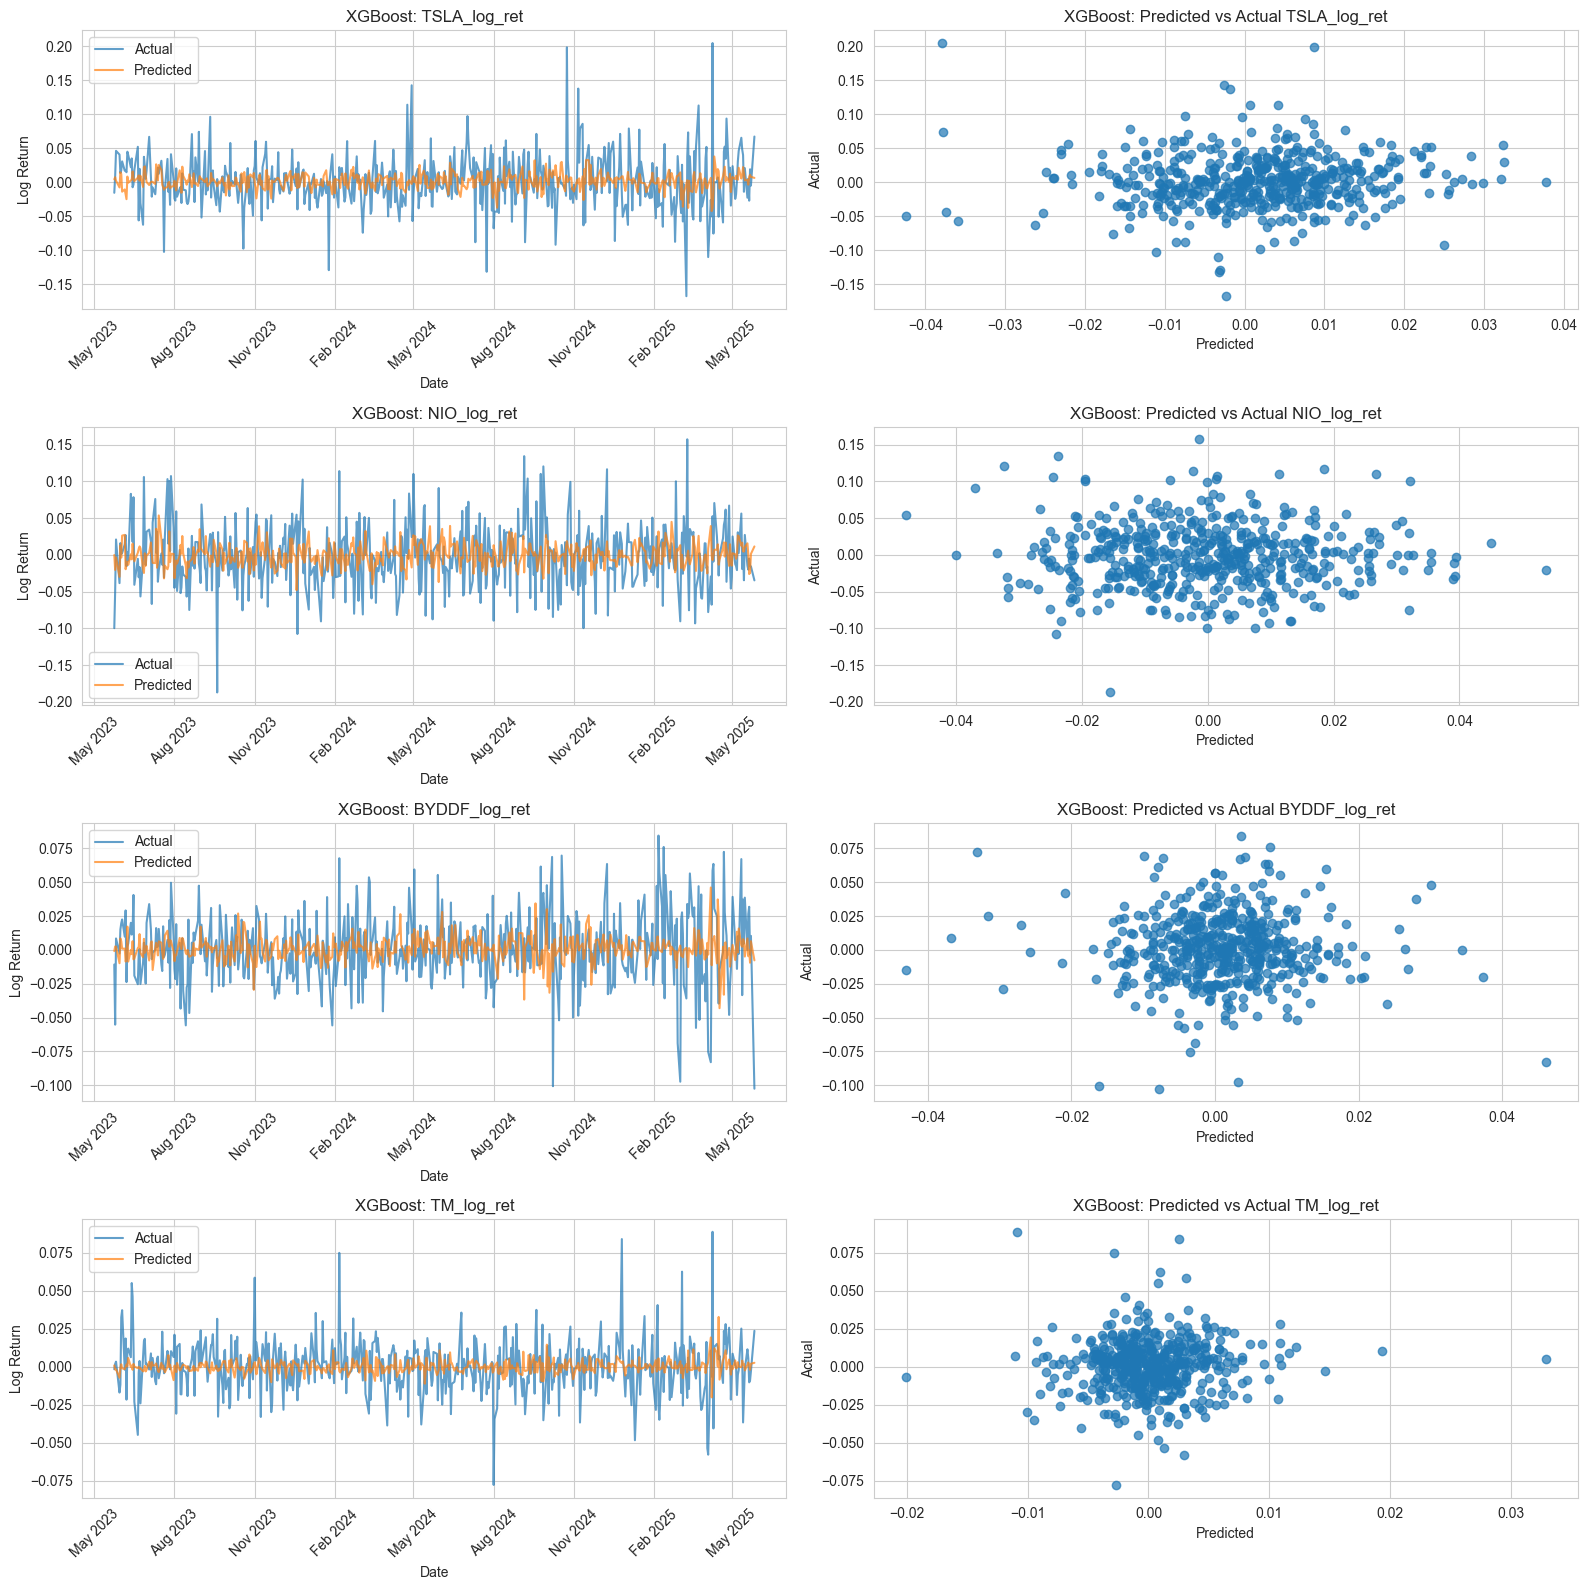

In [11]:
# Visualization block (reuse Ridge layout)
def plot_pred_vs_actual(Y_true, Y_pred, title_prefix):
    plt.figure(figsize=(16, 4 * len(targets)))
    for i, tgt in enumerate(targets, 1):
        y_test = Y_true[tgt]
        y_pred = Y_pred[tgt]

        # Time-series
        plt.subplot(len(targets), 2, 2*i - 1)
        plt.plot(y_test.index, y_test, label='Actual', alpha=0.7)
        plt.plot(y_pred.index, y_pred, label='Predicted', alpha=0.7)
        plt.title(f'{title_prefix}: {tgt}')
        plt.xlabel('Date')
        plt.ylabel('Log Return')
        plt.legend()
        plt.grid(True)
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        plt.xticks(rotation=45)

        # Scatter
        plt.subplot(len(targets), 2, 2*i)
        plt.scatter(y_pred, y_test, alpha=0.7)
        plt.title(f'{title_prefix}: Predicted vs Actual {tgt}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.grid(True)

    plt.tight_layout()
    plt.show()

# --- Plot XGBoost ---
plot_pred_vs_actual(Y_test, Y_pred_xgb, "XGBoost")

## LSTM

In [12]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import kerastuner as kt
import shutil
shutil.rmtree("untitled_project", ignore_errors=True)  # zap old tuner files

scaler_x, scaler_y = StandardScaler(), StandardScaler()
X_scaled = scaler_x.fit_transform(X)
Y_scaled = scaler_y.fit_transform(Y)

timesteps  = 10  # sliding window length for sequences
n_features = X_scaled.shape[1]
n_targets  = Y_scaled.shape[1]

def make_sequences(X, Y, steps):
    X_seq, Y_seq = [], []
    for i in range(steps, len(X)):
        X_seq.append(X[i-steps:i])
        Y_seq.append(Y[i])
    return np.asarray(X_seq), np.asarray(Y_seq)

X_seq, Y_seq = make_sequences(X_scaled, Y_scaled, timesteps)

split = int(len(X_seq) * 0.7)          # 70 % chronological split
X_train, X_test = X_seq[:split],  X_seq[split:]
Y_train, Y_test = Y_seq[:split], Y_seq[split:]

# 3. hyper-tunable LSTM builder function
def build_model(hp):
    inp = Input(shape=(timesteps, n_features))

    x = inp
    n_layers = hp.Int('n_lstm_layers', 1, 2)
    for i in range(n_layers):
        x = LSTM(
                units=hp.Int(f'lstm_units_{i}', 32, 128, step=32),
                return_sequences=(i < n_layers - 1)
            )(x)
        x = Dropout(hp.Float(f'dropout_{i}', 0.1, 0.4, step=0.1))(x)

    x = Dense(hp.Int('dense_units', 16, 64, step=16), activation='relu')(x)
    out = Dense(n_targets)(x)

    model = Model(inp, out)

    lr  = hp.Float('lr', 1e-4, 3e-3, sampling='log')
    opt = hp.Choice('optimizer', ['adam', 'rmsprop', 'nadam'])
    if opt == 'adam':
        optimizer = tf.keras.optimizers.Adam(lr)
    elif opt == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(lr)
    else:
        optimizer = tf.keras.optimizers.Nadam(lr)

    model.compile(optimizer=optimizer, loss='mse', metrics=['mse'])
    return model

# 4. run Bayesian hyper-parameter search
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_mse',
    max_trials=30,
    directory="untitled_project",
    overwrite=True
)

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-5)
]

tuner.search(
    X_train, Y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

best_hp    = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.get_best_models(1)[0]

print("best hyper-params:", best_hp.values)

# evaluate best model (MSE per target)
Y_pred_scaled = best_model.predict(X_test)
Y_pred = scaler_y.inverse_transform(Y_pred_scaled)
Y_true = scaler_y.inverse_transform(Y_test)

dates_full = lagged_df.index[timesteps:]             # index that matches Y_seq
test_idx   = dates_full[split:]                      # slice for test portion

Y_pred_df = pd.DataFrame(Y_pred, index=test_idx, columns=targets)
Y_true_df = pd.DataFrame(Y_true, index=test_idx, columns=targets)

# MSE → RMSE → USD loss
mse_lstm  = {tgt: mean_squared_error(Y_true_df[tgt], Y_pred_df[tgt])
             for tgt in targets}
rmse_lstm = {tgt: np.sqrt(mse) for tgt, mse in mse_lstm.items()}

usd_per_unit_error = 0.50
usd_loss_lstm = {tgt: rmse * usd_per_unit_error for tgt, rmse in rmse_lstm.items()}

lstm_results = (pd.DataFrame({
                    "MSE": mse_lstm,
                    "RMSE": rmse_lstm,
                    "USD_Loss": usd_loss_lstm
               })
               .sort_index())

print("=== LSTM – MSE, RMSE, USD Loss ===")
print(lstm_results.round(6))

Trial 30 Complete [00h 00m 05s]
val_mse: 0.826873779296875

Best val_mse So Far: 0.8229193091392517
Total elapsed time: 00h 02m 04s
best hyper-params: {'n_lstm_layers': 1, 'lstm_units_0': 32, 'dropout_0': 0.4, 'dense_units': 48, 'lr': 0.00017414120634033338, 'optimizer': 'nadam', 'lstm_units_1': 96, 'dropout_1': 0.1}
 1/16 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step

/Users/zoetomlinson/miniconda3/envs/ESGStockPriceModel/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 17 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
=== LSTM – MSE, RMSE, USD Loss ===
                    MSE      RMSE  USD_Loss
BYDDF_log_ret  0.000676  0.025995  0.012997
NIO_log_ret    0.001845  0.042948  0.021474
TM_log_ret     0.000317  0.017804  0.008902
TSLA_log_ret   0.001578  0.039726  0.019863


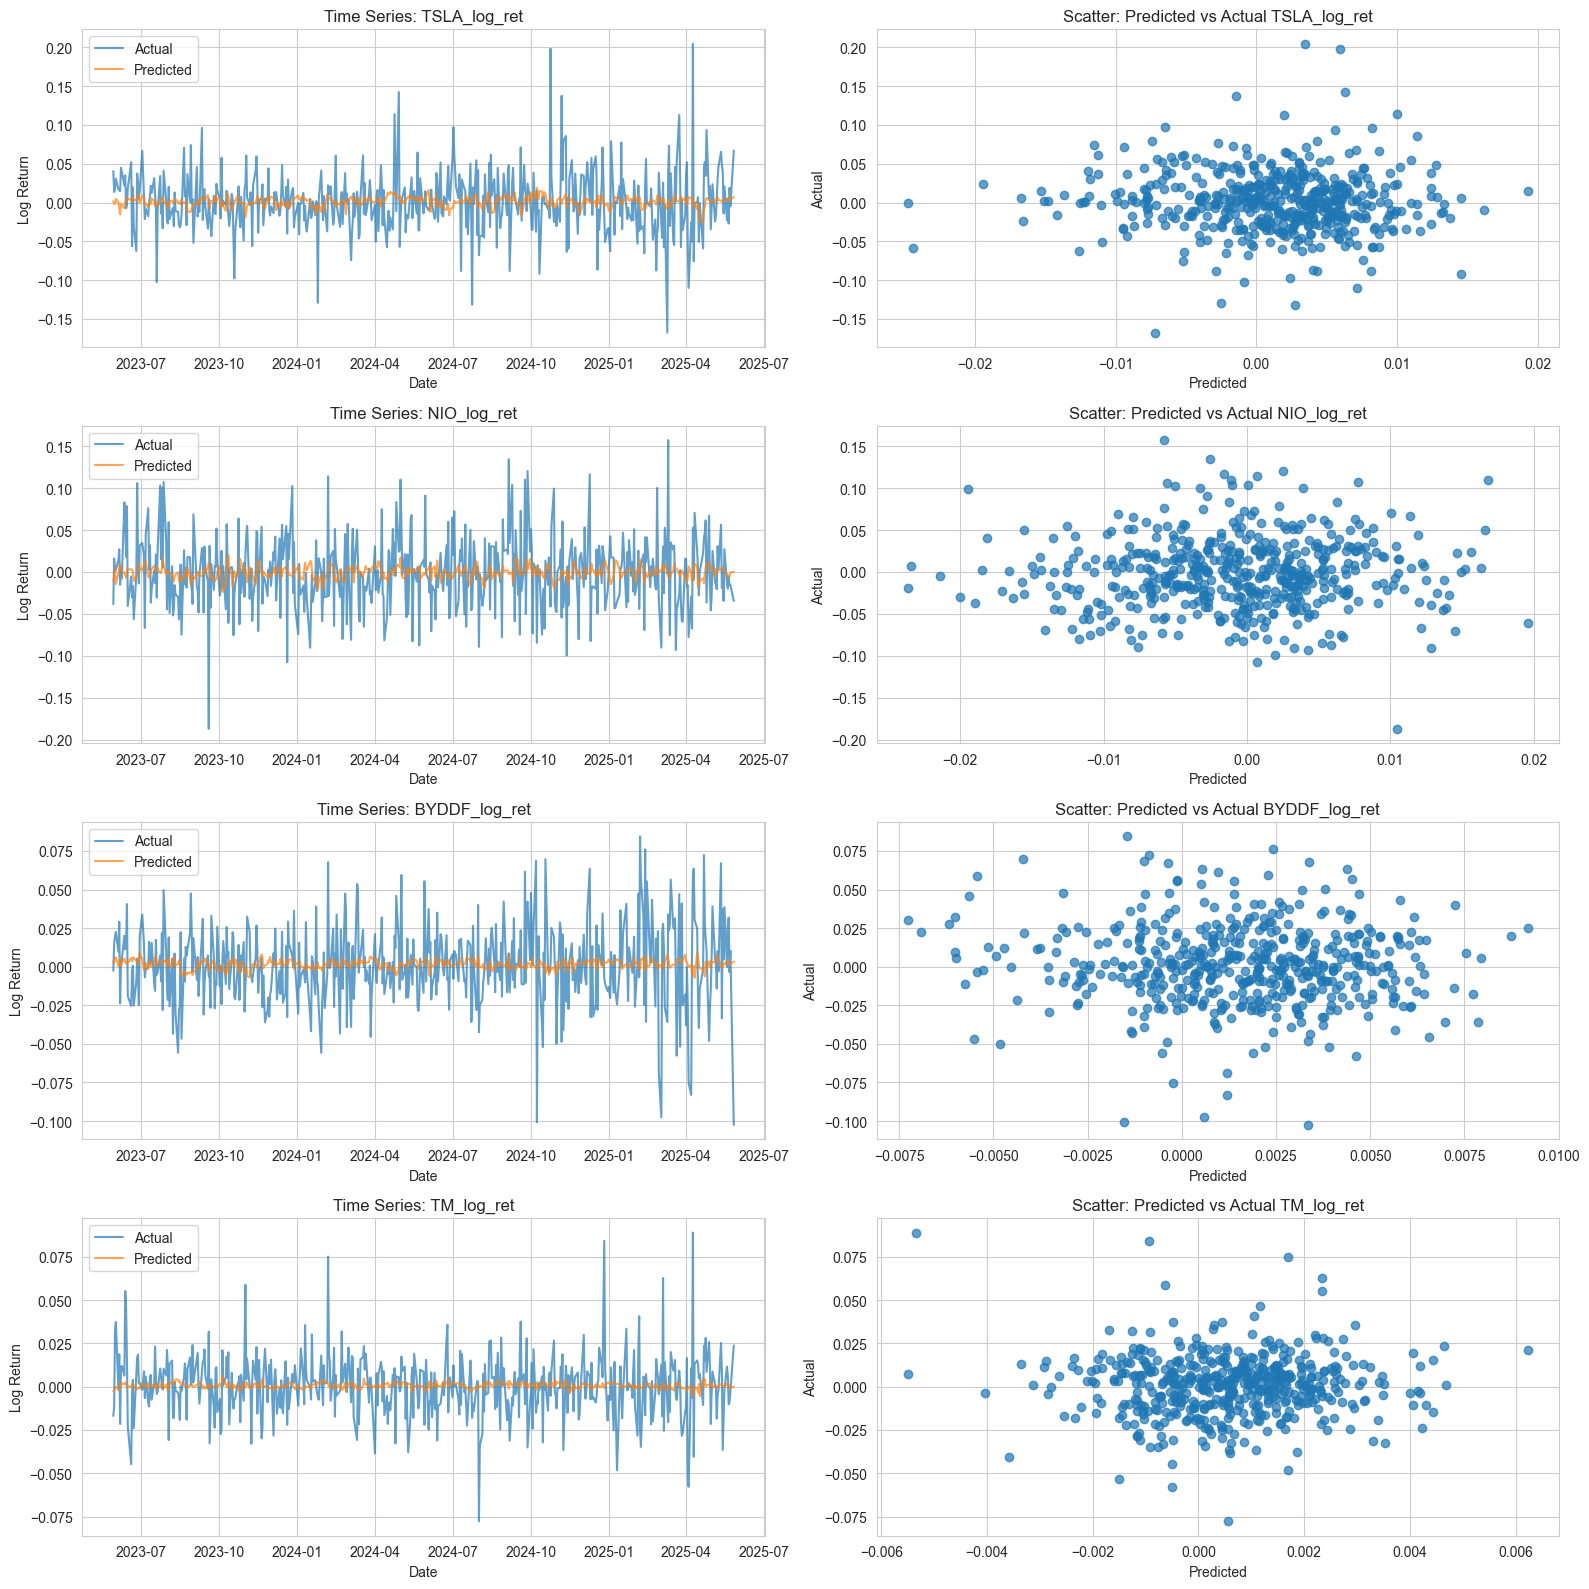

In [13]:
# visualizations: actual vs predicted time series + scatter
plt.figure(figsize=(16, 4 * n_targets))

for i, target in enumerate(targets, 1):
    # Left: line plot (actual vs predicted over time)
    plt.subplot(n_targets, 2, 2*i - 1)
    plt.plot(lagged_df.index[-len(Y_test):], Y_true[:, i-1], label='Actual', alpha=0.7)
    plt.plot(lagged_df.index[-len(Y_test):], Y_pred[:, i-1], label='Predicted', alpha=0.7)
    plt.title(f"Time Series: {target}")
    plt.xlabel("Date")
    plt.ylabel("Log Return")
    plt.legend()
    plt.grid(True)

    # Right: scatter plot (predicted vs actual)
    plt.subplot(n_targets, 2, 2*i)
    plt.scatter(Y_pred[:, i-1], Y_true[:, i-1], alpha=0.7)
    plt.title(f"Scatter: Predicted vs Actual {target}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.grid(True)

plt.tight_layout()
plt.show()